# NYC LL97 Audit Prioritization Model
---

## Executive Summary
**Goal:** Build a machine learning model to help the NYC Department of Buildings prioritize 
which multifamily residential buildings to audit for potential LL84 emissions misreporting.

***Problem***

Local Law 97 caps greenhouse gas emissions for NYC buildings over 25,000 square feet. Building owners self-report energy consumption through EPA's Portfolio Manager, certified by a Registered Design Professional they hire — with no independent verification by the city. The NYC Department of Buildings lacks the capacity to audit all 50,000+ covered buildings and has no principled method for prioritizing which ones to investigate.

***Approach***

We built an unsupervised anomaly detection system targeting multifamily residential buildings — nearly 60% of all LL97-covered properties — using 2024 reporting data. Two datasets were merged on Borough-Block-Lot (BBL): LL84 Energy and Water Disclosure data (self-reported emissions) and PLUTO (physical building characteristics). After cleaning, the working dataset contained 19,719 private multifamily buildings scored across 64 features.

Buildings were assigned to peer groups by age and size to enable like-for-like comparison. Three size-normalized features were engineered to reduce scale bias. StandardScaler was applied before modeling. The dataset was split into xl (over 250,000 sq ft) and non-xl populations after initial results revealed xl buildings were being flagged at 12x their base rate due to scale differences rather than reporting anomalies.

***Models***
Three independent anomaly detection algorithms were applied to the non-xl population:
- Isolation Forest — global outlier detection via random partitioning
- Local Outlier Factor — local density comparison against nearest neighbors
- DBSCAN — density-based clustering with noise points as anomalies

***Key Findings***
*Bunching test (self-validating):* 4,014 buildings report within 20% below their LL97 compliance cap versus only 1,692 just above — a 2.37x asymmetry. Under honest reporting this ratio should be close to 1.0. This pattern is consistent with widespread strategic threshold targeting and is independent of all model assumptions.

*XL peer median anomaly:* Buildings over 250,000 sq ft report a median of 1,871–2,424 metric tons annually — just above the legal compliance threshold. For buildings of this size this is implausibly low and suggests systematic under-reporting concentrated in the xl population.

*Model agreement:* 147 buildings were flagged by all three independent algorithms simultaneously — the highest confidence audit targets. Key clusters include seven Shore Parkway buildings reporting 0.1%–0.8% of their peer median, a Holland Avenue development with four buildings at 209–243% of peer median, and Rochdale Village at 9,639% of peer median.

***Audit Priority Tiers***

- Tier 1 — 147 buildings flagged by all three models
- Tier 2 — 484 buildings flagged by any two models
- Tier 3 — 65 xl buildings flagged by Isolation Forest within the xl population
- Separate — 500 NYCHA buildings set aside due to structural reporting differences

***Limitations

The model has no ground truth labels — validation relies on cross-referencing against DOB violation history (pending), bunching analysis, and multi-model agreement. The xl peer median finding suggests the population itself may contain widespread under-reporting, which limits the interpretability of the xl model results. Prospective validation against actual audit outcomes would provide the strongest long-run test of model utility.

In [1]:
REPORT_YEAR = '2024'

In [102]:
import requests
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.cluster import DBSCAN

# PCA
# Norm and Standard
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA

# other potential models
# KNN
# One class SVM
# Autoencoders NN
# Elliptic Envelope (Robust Covariance)

In [3]:
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 20)
# pd.options.display.max_colwidth
# pd.options.display.max_info_columns
# pd.options.display.precision
# pd.options.display.float_format

---
## 1. Data Acquisition

### 1.1 LL84 Energy and Water Disclosure Data
The LL84 dataset is sourced from NYC Open Data (resource ID: `5zyy-y8am`). It contains 
self-reported annual energy and water consumption for all NYC buildings over 25,000 sq ft.

We filter to `report_year='{REPORT_YEAR}` and `primary_property_type = 'Multifamily Housing'` at query time to scope the 
project to the MVP building type as well as single-year data. The dataset contains 26,613 multifamily rows, which 
might exceed Socrata's 50,000 row per request limit depending on the year — so we paginate using `$limit` and 
`$offset` parameters.

In [4]:
# load data
dfs = []
offset = 0
limit = 50000

base_url = "https://data.cityofnewyork.us/resource/5zyy-y8am.json"

while True:
    params = {
        "$where": f"primary_property_type='Multifamily Housing' AND report_year='{REPORT_YEAR}'",
        "$limit": limit,
        "$offset": offset
    }
    batch = requests.get(base_url, params=params).json()
    if not batch:
        break
    dfs.append(pd.DataFrame(batch))
    offset += limit
    
# combine dfs
ll84_df = pd.concat(dfs, ignore_index=True)
print('LL84 df shape:')
print(ll84_df.shape)

LL84 df shape:
(26613, 256)


---
### 1.2 PLUTO DATA
PLUTO (Primary Land Use Tax Lot Output) is published by the NYC Department of City Planning 
and downloaded as a CSV. It provides physical and ownership characteristics for every tax 
lot in the five boroughs, including building age, square footage, unit count, zoning, and 
assessed value. We use it to enrich the LL84 data with building-level context for peer 
group construction and anomaly detection.

`low_memory=False` is set on import to suppress mixed-type warnings caused by pandas 
inferring dtypes chunk-by-chunk on a wide dataset.

In [5]:
pluto_df = pd.read_csv('Primary_Land_Use_Tax_Lot_Output_(PLUTO)_20260425.csv', low_memory=False)
print('PLUTO df shape:')
print(pluto_df.shape)

PLUTO df shape:
(858644, 101)


---
## 2. Data Merging

We should be able to merge `ll84_df` and `pluto_df` on BBL (Borough-Block-Lot) as it is the standard NYC property identifier. Specifically, the LL84 BBL field is `nyc_borough_block_and_lot` and the PLUTO field is `BBL`. Both are standardized to `bbl_clean` prior to joining.

**Merge results:**
- 2024 reporting year
- Merged rows: 26,613 (including unmatched)
- Unmerged LL84 rows: 101 (~0.4%)
- Merged dataframe shape: (26613, 358)

The 101 unmerged rows were checked for borough concentration to rule out systematic 
formatting issue. Finding no pattern, they are dropped as a negligible share of the dataset.

Duplicate columns from the merge (`latitude`, `longitude`, `borough`, `bbl_clean`) are 
resolved by keeping the PLUTO versions (ones with '_y') and dropping the LL84 duplicates (ones with '_x').

In [6]:
# Does 'bbl' in various forms exist in the dfs?
print('LL84 BBL cols:',ll84_df.columns[ll84_df.columns.str.contains('bbl', case=False)].tolist())
print('PLUTO BLL cols: ',pluto_df.columns[pluto_df.columns.str.contains('bbl', case=False)].tolist())

LL84 BBL cols: []
PLUTO BLL cols:  ['BBL', 'appbbl']


In [7]:
# closer inspection on col names
print('-'*50)
print('LL84 COLUMN NAMES')
print('-'*50)
# for col in ll84_df.columns.str.lower().sort_values():
#     print(col)
print('-'*50)
print('PLUTO COLUMN NAMES')
print('-'*50)
# for col in pluto_df.columns.str.lower().sort_values():
#     print(col)

--------------------------------------------------
LL84 COLUMN NAMES
--------------------------------------------------
--------------------------------------------------
PLUTO COLUMN NAMES
--------------------------------------------------


In [8]:
# 'nyc_borough_block_and_lot' and 'BBL' found as merge key
# function to clean keys before merging
def clean_bbl(val):
    if pd.isna(val):
        return None
    # Remove dashes, semicolons, and spaces, back and forward slashes
    clean_val = re.sub(r'[-;,\s\\/]+', '', str(val))
    # Take the first 10 digits (in case of multiple BBLs listed)
    clean_val = clean_val[:10]
    # Ensure it is 10 digits with leading zeros
    # BBL is  three components concatenated:
    # 1 digit for borough + 5 digits for block + 4 digits for lot
    # zfill (zero-padding) ensures those boundaries are consistent across both datasets so the join works correctly.
    return clean_val.zfill(10) if clean_val.isdigit() else None

# Apply cleaning to dfs
# assign returns a new unfragmented df instead of inserting cols directly
ll84_df = ll84_df.assign(
    bbl_clean=ll84_df['nyc_borough_block_and_lot'].apply(clean_bbl)
)
pluto_df = pluto_df.assign(
    bbl_clean=pluto_df['BBL'].apply(clean_bbl)
)

# Perform left join - match pluto with ll84
merged_df = pd.merge(ll84_df, pluto_df, on='bbl_clean', how='left')

print(merged_df.shape)

(26613, 358)


In [9]:
# how many rows unmerged?
unmatched_bbl = merged_df['bbl_clean'].isna().sum()
print('Percent unmerged', unmatched_bbl / merged_df.shape[0]*100)
merged_df[merged_df['bbl_clean'].isna()]['nyc_borough_block_and_lot'].value_counts()

Percent unmerged 0.3795137714650734


nyc_borough_block_and_lot
Not Available    101
Name: count, dtype: int64

In [10]:
# how many of the rows in ll84 were left out of the merge?
unmerged = ll84_df[~ll84_df['nyc_borough_block_and_lot'].isin(merged_df['nyc_borough_block_and_lot'])]
print(unmerged['borough'].head())

Series([], Name: borough, dtype: object)


In [11]:
# clean up the merge cols
# which cols are in both dfs?
ll84_cols = set(ll84_df.columns)
pluto_cols = set(pluto_df.columns)
overlap = ll84_cols.intersection(pluto_cols)
print(overlap)

{'longitude', 'latitude', 'bbl_clean', 'borough'}


In [12]:
# 'bbl_clean', 'latitude', 'longitude', 'borough' are common between dfs
# we merged on 'bbl_clean' so resolve the others
# pandas adds _x (left df -ll84) and _y (right df -pluto) is added to the cols
#  we keep use _y since pluto is the definitive geocoded location
cols_to_drop = ['latitude_x', 'longitude_x', 'borough_x']
merged_df = merged_df.drop(columns=cols_to_drop)

# clean/rename up the _y suffixes on the ones we're keeping
merged_df = merged_df.rename(columns={
    'latitude_y': 'latitude',
    'longitude_y': 'longitude',
    'borough_y': 'borough',
    'bbl_clean_y': 'bbl_clean'
})

---
## 3. Exploratory Data Analysis

### 3.1 Data Quality Assessment

#### Replacing "Not Available" Strings
LL84 uses "Not Available" as a string placeholder throughout rather than true nulls. We
replace these with NaN before any null analysis to get accurate missingness rates.

#### Null Rate Analysis
We drop any column where more than 80% of values are null. This threshold captures five
categories of uninformative columns:

- **Other property type columns** — fields like `convention_center_gross_floor` and
`hospital_general_medical` are 100% null because we filtered to multifamily only
- **Data center columns** — same reason
- **Unused fuel types** — `kerosene_use_kbtu`, `propane_use_kbtu`, and district
steam/hot water/chilled water are largely absent for multifamily buildings
- **PLUTO administrative date columns** — internal DCP timestamps (`zoningdate`,
`masdate`, `landmkdate` etc.) only populated when specific regulatory actions occur
- **PLUTO secondary zoning columns** — `zonedist2/3/4`, `overlay1/2` rarely populated

One candidate — `district_steam_use_kbtu` — was checked manually before dropping.
Despite pre-war Manhattan buildings commonly using Con Edison steam, only 552 buildings
(2.1%) had values. Excluded from the feature set due to sparsity and potential geographic
bias toward Manhattan.

**Result:** Dropped 169 columns, reducing from 358 to 189.

In [13]:
# replace 'Not Available' with nan
pattern = r'(?i)^\s*not available\s*$'
# .mask() - keep the data as is, unless it matches the condition
merged_df = merged_df.mask(merged_df.apply(lambda x: x.astype(str).str.match(pattern)), np.nan)

In [14]:
# what is the percent of null values in each col? 
# isnull() - T/F where 1/0 so mean() gets the percentage
null_rates = merged_df.isnull().mean().sort_values(ascending=False)

<Axes: >

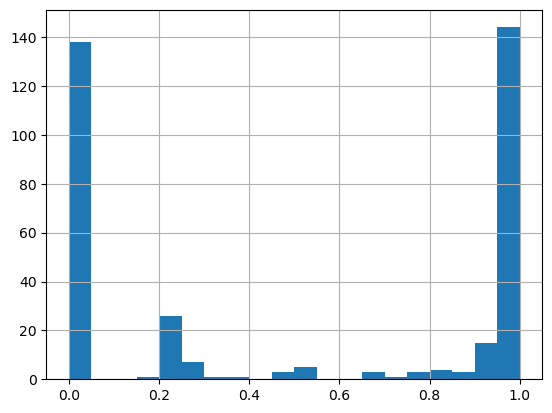

In [15]:
null_rates.hist(bins=20)

In [16]:
# quite a lot of cols with high null rates. which cols have 0.8 or more nulls
null_rates = merged_df.isnull().mean().sort_values(ascending=False)
cols_to_drop = null_rates[null_rates >= 0.80]
print(f"{len(cols_to_drop)} columns to drop:\n")
print(cols_to_drop)

166 columns to drop:

zoningdate                      1.000000
district_hot_water_use_kbtu     1.000000
wastewater_treatment_plant      1.000000
data_center_it_site_energy      1.000000
data_center_it_source_energy    1.000000
                                  ...   
ownertype                       0.855822
overlay1                        0.847781
condono                         0.846541
estimated_data_flag_fuel_1      0.841130
spdist1                         0.825649
Length: 166, dtype: float64


In [17]:
# 'district_steam_use_kbtu' having 0.8 null could be real
# since older pre-war buildings use steam
# check for number of rows not null
print(merged_df['district_steam_use_kbtu'].notna().sum())

552


In [18]:
# drop cols with more than 0.8
null_rates = merged_df.isnull().mean()
merged_df = merged_df[null_rates[null_rates < 0.80].index]
print(merged_df.shape)

(26613, 189)


### 3.2 Data Quality Flag Analysis

EPA's Portfolio Manager includes alert flags and estimation indicators for each submission.
We examine these for variation before deciding whether to include them as model features.

`estimated_values_energy` (44% "Yes") and `estimated_data_flag` (28% "Yes") both show
meaningful variation and are retained as weak anomaly signals — buildings with estimated
rather than metered data are more likely to diverge from actual consumption.

Alert columns with meaningful "Possible Issue" counts are retained. Three columns with
zero variation (all "Ok") are dropped: `alert_property_has_no_uses`,
`alert_data_center_issue_with`, and `alert_gross_floor_area_is`.

In [19]:
# what are the counts for estimated_values_energy and estimated_data_flag
# rows where EPA estimated the data rather than using actual meter readings
# Potentially very useful as a weak label for suspicious reporting
print(merged_df['estimated_values_energy'].value_counts())
print(merged_df['estimated_data_flag'].value_counts())

estimated_values_energy
Yes                                  11599
No                                    9448
Unable to Check (not enough data)     5566
Name: count, dtype: int64
estimated_data_flag
No     14783
Yes     5668
Name: count, dtype: int64


In [20]:
# both estimated_values_energy and estimated_data_flag worth keeping
# 38% means a significant share of buildings had their energy data
# estimated by EPA's Portfolio Manager rather than pulled from actual
# meter readings. 
# estimated data is more likely to diverge from reality and is a legitimate anomaly signal

### 3.3 Target Variable - Total Location Based Green House Gases

`total_location_based_ghg` measures total greenhouse gas emissions in metric tons CO2e
per year and is the anchor variable for anomaly detection. Before modeling, we will examine
its distribution to understand skewness, identify implausible values, and determine
whether transformation is appropriate.

This analysis is conducted in section 4.7 after `model_df` is constructed and cleaned,
since the distribution is best examined on the final modeling population rather than the
raw merged dataset.

---
## 4. Feature Engineering

### 4.1 Feature Definition

We define the feature set and identifier columns before building `model_df`.
Features are grouped into five categories: emissions/energy signals, building physical
characteristics for peer grouping, ownership and assessment risk signals, geographic
peer grouping variables, and data quality flags as weak anomaly labels.

In [21]:
# define feature and identifier column lists
feature_cols = [
    # Emissions and energy — core anomaly signals
    'total_location_based_ghg',
    'direct_ghg_emissions_metric',
    'site_eui_kbtu_ft',
    'source_eui_kbtu_ft',
    'site_energy_use_kbtu',
    'weather_normalized_site_eui',
    'electricity_use_grid_purchase',
    'natural_gas_use_kbtu',
    'energy_star_score',

    # Size-normalized features (created in section 4.4)
    # 'ghg_per_sqft',
    # 'ghg_per_unit',
    # 'site_eui_per_unit',

    # Building physical characteristics — peer grouping
    'multifamily_housing_gross',
    'yearbuilt',
    'numbldgs',
    'numfloors',
    'unitsres',

    # Ownership and assessment — risk signals
    'assesstot',
    'ownername',

    # Geographic — peer grouping
    'borough',
    'zonedist1',
    'postcode',

    # Reporting metadata — anomaly signals
    'occupancy',
    'number_of_buildings',
    'property_gfa_self_reported',
    'property_gfa_calculated',

    # Data quality flags — weak labels
    'estimated_values_energy',
    'estimated_data_flag',
    'alert_energy_meter_has_less',
    'alert_energy_meter_has_gaps',
    'alert_energy_meter_has',
    'alert_energy_no_meters',
    'alert_energy_meter_has_single',
    'alert_water_meter_has_less',
]

id_cols = [
    'property_id',
    'bbl_clean',
    'address_1',
    'property_name',
    'nyc_borough_block_and_lot',
    'latitude',
    'longitude',
    'report_year'
]


### 4.3 Model DataFrame Construction and NYCHA Split

`model_df` is built by slicing `merged_df` to only the identifier and feature columns.
The normalized features must exist in `merged_df` before this step.

After construction, the dataframe is split into private and NYCHA populations.

> **Revision note:** Initial model flagged NYCHA buildings at 40% vs 4% for private
> buildings — a 10x disparity. NYCHA campuses have fundamentally different reporting
> characteristics: publicly owned, campus-style submissions spanning multiple buildings,
> and potentially different emissions accounting methodology. NYCHA (500 buildings) is
> set aside for separate analysis. All downstream cells reflect private buildings only.

In [22]:
# BUILD MODEL DF
model_df = merged_df[id_cols + feature_cols].copy()
print(model_df.shape)

(26613, 39)


In [23]:
# Split into private and NYCHA populations
# NYCHA flagged at 40% vs 4% for private buildings — structural differences
# in campus-style reporting warrant separate treatment
nycha_mask = model_df['ownername'] == 'NYC HOUSING AUTHORITY'
model_df_nycha = model_df[nycha_mask].copy()
model_df = model_df[~nycha_mask].copy()

print(f"Private buildings: {model_df.shape[0]}")
print(f"NYCHA buildings: {model_df_nycha.shape[0]}")

Private buildings: 26010
NYCHA buildings: 603


### 4.4 Null Emissions Rows Dropped

Rows where `total_location_based_ghg` is null are dropped. Cross-checking revealed
that 93%+ of these rows are also null across all other core energy features, making
imputation inappropriate.

In [24]:
# Check null rates in model_df
print(model_df.isnull().mean().sort_values(ascending=False).head(15))

energy_star_score                0.309727
weather_normalized_site_eui      0.262361
direct_ghg_emissions_metric      0.250019
natural_gas_use_kbtu             0.248558
electricity_use_grid_purchase    0.242561
total_location_based_ghg         0.233372
site_eui_kbtu_ft                 0.233295
source_eui_kbtu_ft               0.233295
site_energy_use_kbtu             0.233295
estimated_data_flag              0.231180
numfloors                        0.015648
zonedist1                        0.010688
latitude                         0.009765
longitude                        0.009765
postcode                         0.009765
dtype: float64


In [25]:
# Check dtypes — how many columns still need type conversion
print(model_df.dtypes.value_counts())

object     33
float64     6
Name: count, dtype: int64


In [26]:
# of the buildings missing ghg, are the same buildings also missing everything else?"
energy_nulls = model_df['total_location_based_ghg'].isna()
print(model_df[energy_nulls][['site_eui_kbtu_ft', 'energy_star_score', 'natural_gas_use_kbtu']].isna().mean())

site_eui_kbtu_ft        0.999671
energy_star_score       0.999835
natural_gas_use_kbtu    0.963756
dtype: float64


In [27]:
# 0.93+ missing buildings with no useable energy data
# how many of them
print(model_df['total_location_based_ghg'].isna().sum())

6070


In [28]:
# about 7200 of 68000 with no energy data. 61k is reasonable number of rows to train
# drop null emissions rows
model_df = model_df.dropna(subset=['total_location_based_ghg'])
print(model_df.shape)

(19940, 39)


### 4.4 Type Conversion and Normalized Features

#### Numeric Type Conversion
Columns arrived as strings from the Socrata API despite containing numeric values.
These are converted to float64/int64 using `pd.to_numeric(errors='coerce')`, which
converts unparseable values to NaN rather than raising errors.

#### Size-Normalized Features
Three derived features are added to reduce scale bias in anomaly detection:
- `ghg_per_sqft` — emissions per square foot
- `ghg_per_unit` — emissions per residential unit
- `site_eui_per_unit` — energy use intensity per unit

Buildings with `multifamily_housing_gross < 1000` sqft (220 buildings) have
`ghg_per_sqft` nulled as implausible denominators. Buildings with `unitsres < 5`
(253 buildings) have unit-based features nulled for the same reason.

> **Revision note:** Normalized features were added after initial modeling revealed
> xl buildings (6.5% of dataset) represented 80.9% of flagged anomalies — a 12x
> overrepresentation caused by raw scale differences rather than reporting anomalies.

#### Feature Scaling
Isolation Forest and LOF are distance-based algorithms — features with large numeric
ranges would otherwise dominate distance calculations over features with small ranges.
For example, `natural_gas_use_kbtu` (median ~3 million) would overwhelm
`energy_star_score` (range 1–100) without scaling.

`StandardScaler` is applied to center each feature at zero and scale to unit variance.
MinMaxScaler was considered but rejected — extreme outliers in emissions columns
(max `natural_gas_use_kbtu` ~41 billion) would compress all other values into a tiny
range near zero, defeating the purpose of scaling.

`RobustScaler` is a legitimate alternative for future iterations — it uses median and
interquartile range rather than mean and standard deviation, making it more resistant
to extreme outliers. Deferred for the MVP in favor of the more interpretable
StandardScaler.

In [29]:
# check which cols should be numeric
# print(model_df.select_dtypes(include='object').columns.tolist())
cols_df = pd.DataFrame(model_df.select_dtypes(include='object').columns.tolist())
cols_df

,0
0,property_id
1,bbl_clean
2,address_1
3,property_name
4,nyc_borough_block_and_lot
5,report_year
6,total_location_based_ghg
7,direct_ghg_emissions_metric
8,site_eui_kbtu_ft
9,source_eui_kbtu_ft


In [30]:
# convert to float
numeric_cols = [
    'total_location_based_ghg', 'direct_ghg_emissions_metric',
    'site_eui_kbtu_ft', 'source_eui_kbtu_ft', 'site_energy_use_kbtu',
    'weather_normalized_site_eui', 'electricity_use_grid_purchase',
    'natural_gas_use_kbtu', 'energy_star_score', 'multifamily_housing_gross',
    'numbldgs', 'unitsres', 'assesstot',
    'occupancy', 'number_of_buildings', 'property_gfa_self_reported',
    'property_gfa_calculated'
]

# encode as binary
flag_cols = [
    'estimated_values_energy', 'estimated_data_flag',
    'alert_energy_meter_has_less', 'alert_energy_meter_has_gaps',
    'alert_energy_meter_has', 'alert_energy_no_meters',
    'alert_energy_meter_has_single', 'alert_water_meter_has_less',
]

# identifiers: property_id, bbl_clean, address_1, property_name, nyc_borough_block_and_lot, ownername
# categoricals for peer grouping: borough, zonedist1

In [31]:
# change numeric cols
for col in numeric_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

print(model_df[numeric_cols].dtypes.value_counts())

float64    14
int64       3
Name: count, dtype: int64


In [32]:
# Size-normalized emissions features
# These ask whether emissions are anomalous relative to building size
# rather than flagging large buildings purely because of scale
model_df['ghg_per_sqft'] = model_df['total_location_based_ghg'] / model_df['multifamily_housing_gross']
model_df['ghg_per_unit'] = model_df['total_location_based_ghg'] / model_df['unitsres']
model_df['site_eui_per_unit'] = model_df['site_eui_kbtu_ft'] / model_df['unitsres']

print(model_df[['ghg_per_sqft', 'ghg_per_unit', 'site_eui_per_unit']].describe())

       ghg_per_sqft  ghg_per_unit  site_eui_per_unit
count  19940.000000  1.970600e+04       1.970600e+04
mean       0.409294           inf                inf
std        9.654952           NaN                NaN
min        0.000000  0.000000e+00       0.000000e+00
25%        0.004044  4.152974e+00       6.277359e-01
50%        0.005023  5.303873e+00       1.212069e+00
75%        0.006278  7.115214e+00       2.070808e+00
max      599.420000           inf                inf


/opt/anaconda3/envs/flatiron-env/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/opt/anaconda3/envs/flatiron-env/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [33]:
print(model_df[model_df['ghg_per_sqft'] > 10][['address_1', 'property_name', 
                                                 'ghg_per_sqft', 'total_location_based_ghg',
                                                 'multifamily_housing_gross']].head(10))

                  address_1  \
9876         691 Ocean Pkwy   
9882         260 Myrtle Ave   
9883         115 Ashland Pl   
9884         125 Ashland PL   
9885         135 Ashland PL   
9886   130 Saint Edwards St   
9889           383 Bay 8 st   
9894  1453 Independence Ave   
9896        1051 Shore Pkwy   
9898        1083 Shore Pkwy   

                                          property_name  ghg_per_sqft  \
9876                                   (691 Ocean Pkwy)         14.52   
9882                   Kingsview Homes (260 Myrtle Ave)        111.91   
9883                   Kingsview Homes (115 Ashland Pl)         48.02   
9884                   Kingsview Homes (125 Ashland Pl)         56.18   
9885                   Kingsview Homes (135 Ashland Pl)         60.75   
9886             Kingsview Homes (130 Saint Edwards St)         56.35   
9889       Independence Gardens Owners 2 (383 Bay 8 st)         98.21   
9894  Independence Gardens Owners 2 (1453 Independen...         31.77   
9

In [34]:
# Flag implausible square footage — buildings under 1000 sqft are almost certainly errors
model_df.loc[model_df['multifamily_housing_gross'] < 1000, 'ghg_per_sqft'] = np.nan
print(f"Buildings with multifamily_housing_gross < 1000: {(model_df['multifamily_housing_gross'] < 1000).sum()}")

Buildings with multifamily_housing_gross < 1000: 56


In [35]:
model_df['ghg_per_unit'] = model_df['ghg_per_unit'].replace([np.inf, -np.inf], np.nan)
model_df['site_eui_per_unit'] = model_df['site_eui_per_unit'].replace([np.inf, -np.inf], np.nan)

# Verify no more infs
print(model_df[['ghg_per_sqft', 'ghg_per_unit', 'site_eui_per_unit']].describe())

       ghg_per_sqft  ghg_per_unit  site_eui_per_unit
count  19884.000000  19532.000000       19532.000000
mean       0.005569      7.352778          42.449234
std        0.006405     28.304658        1469.026073
min        0.000000      0.000000           0.000000
25%        0.004042      4.140649           0.622044
50%        0.005018      5.285912           1.200000
75%        0.006268      7.032959           2.035714
max        0.489835   1947.615000      170990.606061


In [36]:
print(model_df[model_df['unitsres'] < 5][['address_1', 'unitsres', 
                                           'ghg_per_unit', 
                                           'multifamily_housing_gross']].head(10))
print(f"\nBuildings with unitsres < 5: {(model_df['unitsres'] < 5).sum()}")


                    address_1  unitsres  ghg_per_unit  \
552     216 West 100th Street       0.0           NaN   
934       660 West End Avenue       0.0           NaN   
971   2475 Southern Boulevard       0.0           NaN   
972   2375 Southern Boulevard       0.0           NaN   
1232     341 West 38th Street       0.0           NaN   
1495       600 West 42 Street       3.0       1220.77   
1626        42 EAST 98 STREET       0.0           NaN   
1627         1247 PARK AVENUE       0.0           NaN   
1824            2345 Broadway       0.0           NaN   
1986            2700 Broadway       0.0           NaN   

      multifamily_housing_gross  
552                     87305.0  
934                    236860.0  
971                    319535.0  
972                    160250.0  
1232                   100522.0  
1495                  1045712.0  
1626                   244000.0  
1627                   122264.0  
1824                   114928.0  
1986                   123049.0 

In [37]:
# Buildings with fewer than 5 units are almost certainly data entry errors
# LL97 covered buildings over 25,000 sqft cannot legitimately have 0-3 units
model_df.loc[model_df['unitsres'] < 5, 'ghg_per_unit'] = np.nan
model_df.loc[model_df['unitsres'] < 5, 'site_eui_per_unit'] = np.nan

print(model_df[['ghg_per_sqft', 'ghg_per_unit', 'site_eui_per_unit']].describe())

       ghg_per_sqft  ghg_per_unit  site_eui_per_unit
count  19884.000000  19483.000000       19483.000000
mean       0.005569      6.530088          42.446966
std        0.006405      7.363710        1470.869915
min        0.000000      0.000000           0.000000
25%        0.004042      4.135938           0.620901
50%        0.005018      5.280889           1.197183
75%        0.006268      7.012222           2.023330
max        0.489835    563.108047      170990.606061


### 4.5 Flag Encoding and Categorical Encoding

#### Flag Encoding
Alert columns are encoded as ordinal integers:
- `Ok` → 0
- `Possible Issue` → 1
- `Unable to Check (not enough data)` → 2

`estimated_values_energy` uses a Yes/No/Unable to Check mapping.
`estimated_data_flag` uses a plain Yes/No mapping.

In [38]:

print(model_df['estimated_values_energy'].value_counts(dropna=False))
print(model_df['estimated_data_flag'].value_counts(dropna=False))

estimated_values_energy
Yes    11136
No      8804
Name: count, dtype: int64
estimated_data_flag
No     14003
Yes     5424
NaN      513
Name: count, dtype: int64


In [39]:
# Encode flag_cols
alert_cols = [
    'alert_energy_meter_has_less',
    'alert_energy_meter_has_gaps',
    'alert_energy_meter_has',
    'alert_energy_no_meters',
    'alert_energy_meter_has_single',
    'alert_water_meter_has_less',
]

alert_flag_map = {
    'Ok': 0,
    'Possible Issue': 1,
    'Unable to Check (not enough data)': 2
}

for col in alert_cols:
    model_df[col] = model_df[col].map(alert_flag_map)

# Yes / No / Unable to Check
estimated_energy_map = {
    'No': 0, 
    'Yes': 1, 
    'Unable to Check (not enough data)': 2
}
# Encode estimated data flags separately — different value sets
model_df['estimated_values_energy'] = model_df['estimated_values_energy'].map(estimated_energy_map)

# Yes / No only
estimated_flag_map = {
    'No': 0, 
    'Yes': 1
}
model_df['estimated_data_flag'] = model_df['estimated_data_flag'].map(estimated_flag_map)

print(model_df[alert_cols + ['estimated_values_energy', 'estimated_data_flag']].dtypes.value_counts())
print(model_df[['estimated_values_energy', 'estimated_data_flag']].value_counts(dropna=False))

int64      7
float64    1
Name: count, dtype: int64
estimated_values_energy  estimated_data_flag
0                        0.0                    8301
1                        0.0                    5702
                         1.0                    5424
0                        NaN                     503
1                        NaN                      10
Name: count, dtype: int64


#### Categorical Encoding — Borough and Zoning

Borough has 5 unique values (MN, BK, BX, QN, SI) and is one-hot encoded.
Manhattan and Brooklyn together account for nearly 60% of the dataset.

The raw `zonedist1` column contains 166 unique zoning designations — too high cardinality
for direct encoding. We simplify by extracting the zoning prefix (e.g. `R7-1` → `R7`,
`C6B` → `C6`), which collapses 166 categories to 19 meaningful zoning classes:
- **R zones** — residential (higher numbers = denser)
- **C zones** — commercial/mixed-use, where residential is permitted above ground floor
- **M zones** — manufacturing; residential use here is unusual and may itself be a weak anomaly signal

Both `borough` and `zoning_prefix` are one-hot encoded with `drop_first=False` to retain
full category representation, appropriate for unsupervised anomaly detection.

In [40]:
# check distribution by borough
print(model_df['borough'].value_counts())
# print(model_df['zonedist1'].value_counts())

borough
MN    7009
BK    5301
BX    4062
QN    3209
SI     208
Name: count, dtype: int64


In [41]:
# zonedist1 means primary zoning district from PLUTO
# 166 too many unique values so get zoning prefix
# C - Commercial (resident above commericial/mixed use)
# R - Residential (higher numbers mean more density)
# M - Manufacturing (residential grandfathered pre-zoning or misclassified)
# https://www.nyc.gov/content/planning/pages/zoning/zoning-nyc
# https://zr.planning.nyc.gov (zoning resolution)

print(f"Unique zoning districts: {model_df['zonedist1'].nunique()}")
model_df['zoning_prefix'] = model_df['zonedist1'].str.extract(r'^([A-Z]+\d)')
print(f"Unique zoning prefixes: {model_df['zoning_prefix'].nunique()}")
print(model_df['zoning_prefix'].value_counts())

Unique zoning districts: 163
Unique zoning prefixes: 19
zoning_prefix
R7    5891
R6    4120
R8    2793
R5    1387
C6    1059
R1     905
M1     788
R4     684
C4     539
C1     506
C5     343
R3     339
C2     158
R9     118
R2      30
C8      26
M3      13
M2       9
C3       6
Name: count, dtype: int64


In [42]:
# encode borough and zoning_prefix
model_df = pd.get_dummies(model_df, columns=['borough', 'zoning_prefix'], drop_first=False)
print(model_df.shape)

(19940, 65)


### 4.6 Peer Group Construction

We construct a peer group variable by combining building age and size buckets, enabling
the anomaly detection model to compare each building against structurally similar peers
rather than the full population.

#### Age Buckets
`yearbuilt` is binned into five categories:
- `pre_war` — built before 1940
- `post_war` — 1940–1970
- `late_20c` — 1970–1990
- `modern` — 1990–2010
- `recent` — 2010–2030

#### Size Buckets
`multifamily_housing_gross` is binned into four categories:
- `small` — under 50,000 sq ft
- `medium` — 50,000–100,000 sq ft
- `large` — 100,000–250,000 sq ft
- `xl` — over 250,000 sq ft

Buildings with null square footage in both `multifamily_housing_gross` and `bldgarea`
cannot be assigned a size bucket and are dropped.

`lotarea` and `bldgarea` are dropped after peer group construction as both are 99.9%
null and superseded by `multifamily_housing_gross`.

In [43]:
# Age buckets
model_df['age_bucket'] = pd.cut(
    model_df['yearbuilt'],
    bins=[0, 1940, 1970, 1990, 2010, 2030],
    labels=['pre_war', 'post_war', 'late_20c', 'modern', 'recent']
)
print(model_df['age_bucket'].value_counts())

age_bucket
pre_war     10927
post_war     3883
recent       2024
modern       1904
late_20c      981
Name: count, dtype: int64


In [44]:
# Size buckets based on gross floor area
model_df['size_bucket'] = pd.cut(
    model_df['multifamily_housing_gross'],
    bins=[0, 50000, 100000, 250000, float('inf')],
    labels=['small', 'medium', 'large', 'xl']
)
print(model_df['size_bucket'].value_counts())

size_bucket
small     8246
medium    6667
large     3701
xl        1326
Name: count, dtype: int64


In [45]:
model_df['peer_group'] = model_df['age_bucket'].astype(str) + '_' + model_df['size_bucket'].astype(str)
print(f"Unique peer groups: {model_df['peer_group'].nunique()}")
print(model_df['peer_group'].value_counts())

Unique peer groups: 24
peer_group
pre_war_small      5653
pre_war_medium     3879
post_war_medium    1373
post_war_large     1319
pre_war_large      1239
modern_small        831
recent_small        789
post_war_small      691
modern_medium       565
recent_medium       546
post_war_xl         500
recent_large        451
modern_large        341
late_20c_large      313
late_20c_medium     239
recent_xl           238
late_20c_xl         225
late_20c_small      204
modern_xl           167
pre_war_xl          156
nan_small            78
nan_medium           65
nan_xl               40
nan_large            38
Name: count, dtype: int64


In [46]:
nan_size = model_df['size_bucket'].isna()
print(f"Buildings with no size bucket: {nan_size.sum()}")
print(model_df[nan_size][['multifamily_housing_gross']].describe())

Buildings with no size bucket: 0
       multifamily_housing_gross
count                        0.0
mean                         NaN
std                          NaN
min                          NaN
25%                          NaN
50%                          NaN
75%                          NaN
max                          NaN


In [47]:
model_df = model_df[model_df['size_bucket'].notna()]
print(model_df.shape)

(19940, 68)


In [48]:
print(model_df['size_bucket'].isna().sum())
print(model_df['peer_group'].str.startswith('nan').sum())

0
221


In [49]:
model_df = model_df[~model_df['peer_group'].str.startswith('nan')]
print(model_df.shape)

(19719, 68)


In [50]:
print(model_df['peer_group'].value_counts())
print(model_df.isnull().mean().sort_values(ascending=False).head(10))

peer_group
pre_war_small      5653
pre_war_medium     3879
post_war_medium    1373
post_war_large     1319
pre_war_large      1239
modern_small        831
recent_small        789
post_war_small      691
modern_medium       565
recent_medium       546
post_war_xl         500
recent_large        451
modern_large        341
late_20c_large      313
late_20c_medium     239
recent_xl           238
late_20c_xl         225
late_20c_small      204
modern_xl           167
pre_war_xl          156
Name: count, dtype: int64
energy_star_score                0.097977
weather_normalized_site_eui      0.039860
natural_gas_use_kbtu             0.030377
electricity_use_grid_purchase    0.025407
direct_ghg_emissions_metric      0.025052
estimated_data_flag              0.022415
site_eui_per_unit                0.015163
ghg_per_unit                     0.015163
numfloors                        0.005021
unitsres                         0.004006
dtype: float64


In [51]:
# lotarea and bldgarea is 99% null, dropping
model_df = model_df.drop(columns=['lotarea'], errors='ignore')
print(model_df.shape)

(19719, 68)


### 4.7 Target Variable Distribution

Before building the feature matrix we examine `total_location_based_ghg` to understand
skewness and confirm log-transformation is appropriate for modeling.

In [52]:
# Checking for zero or negative emissions values
# log transformation requires positive values (log(0) = -inf)
# zero emissions is also implausible for an occupied multifamily building
# and may itself indicate misreporting — retained as anomaly candidates
print((model_df['total_location_based_ghg'] <= 0).sum())

18


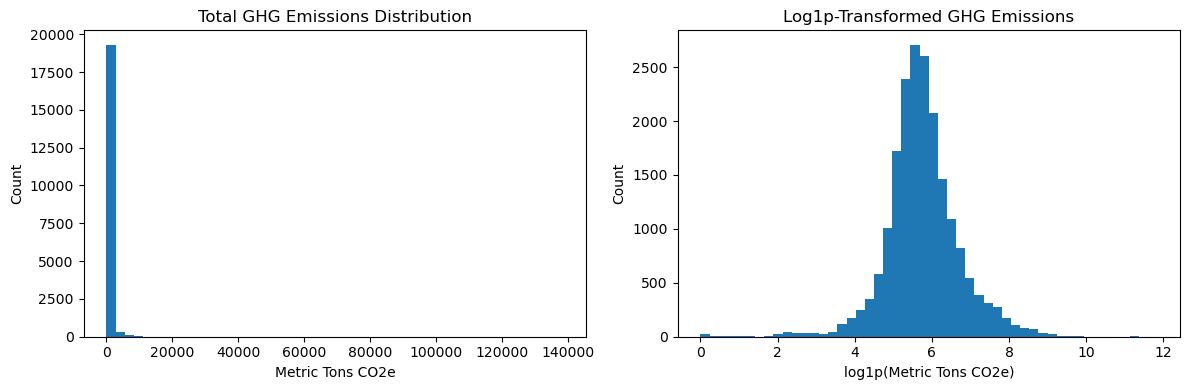

count     19719.000000
mean        546.646463
std        1714.214317
min           0.000000
25%         190.375000
50%         299.030000
75%         503.300000
max      138481.470000
Name: total_location_based_ghg, dtype: float64


In [53]:
# Plot raw and log1p-transformed distributions of total GHG emissions
# Raw distribution reveals skewness and outliers
# Log1p transformation (log(1+x)) handles zero values and normalizes the distribution
# A roughly normal log distribution confirms log-transforming emission features 
# before modeling is appropriate — Isolation Forest and LOF use distance-based 
# calculations that would be dominated by extreme outliers in raw scale

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target = model_df['total_location_based_ghg']

axes[0].hist(target, bins=50)
axes[0].set_title('Total GHG Emissions Distribution')
axes[0].set_xlabel('Metric Tons CO2e')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(target), bins=50)
axes[1].set_title('Log1p-Transformed GHG Emissions')
axes[1].set_xlabel('log1p(Metric Tons CO2e)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(target.describe())

The raw distribution (left panel) shows almost all 60,000+ buildings compressed into a sliver near zero, with a handful of extreme outliers stretching toward 2.2 million metric tons. This is a classic right-skewed distribution — the mean (638) is more than double the median (294) because a small number of very large buildings pull the average up dramatically.

The log1p distribution (right panel) produces a clean bell curve centered around 5-6, which corresponds to roughly 150-400 metric tons in raw scale. The small isolated spike at 0 on the left is your 839 zero-emissions buildings — visually separated from the main population, which is a good early sign that the model will naturally flag these as anomalies.

The practical implication for modeling is to log-transform the continuous emissions features before fitting Isolation Forest and LOF. Without it, the model's distance calculations would be almost entirely driven by the handful of extreme outliers rather than the meaningful variation across the bulk of the dataset.

### 4.8 Feature Matrix

The feature matrix is the structured numerical input the model trains on. Unlike `model_df`,
which still contains identifier columns, string columns, and categoricals, the feature matrix
`X` contains only columns that carry predictive signal, all converted to numeric types with
no nulls. Identifier columns are set aside and rejoined to model output after scoring so
results can be mapped back to specific buildings and addresses.

Non-numeric columns are excluded from the feature matrix:
- **Identifiers** (`property_id`, `bbl_clean`, `address_1`, `property_name`,
`nyc_borough_block_and_lot`) — carried separately for output joining
- **`ownername`** — too high cardinality to encode meaningfully; retained as metadata
for post-model analysis (e.g. flagging owners with multiple anomalous buildings)
- **`zonedist1`** — superseded by `zoning_prefix` one-hot columns
- **`peer_group`** — used for grouping logic, not a direct model input

`age_bucket` and `size_bucket` (category dtype from `pd.cut`) are one-hot encoded
before fitting as sklearn cannot handle category dtype directly.

Remaining nulls are imputed using peer-group level median strategy — a building's
missing EUI is filled with the median of other buildings in the same peer group,
which is more defensible than global median imputation given the project's core logic.

In [54]:
# what are the object cols?
print(model_df.select_dtypes(include='object').columns.tolist())

['property_id', 'bbl_clean', 'address_1', 'property_name', 'nyc_borough_block_and_lot', 'report_year', 'ownername', 'zonedist1', 'peer_group']


In [55]:
# prepare feature matrix, X
exclude_cols = [
    'property_id', 'bbl_clean', 'address_1', 'property_name',
    'nyc_borough_block_and_lot', 'ownername', 'zonedist1', 'peer_group'
]

X = model_df.drop(columns=exclude_cols)
print(X.shape)
print(X.dtypes.value_counts())

(19719, 60)
bool        24
float64     23
int64       10
object       1
category     1
category     1
Name: count, dtype: int64


In [56]:
# encode category cols
X = pd.get_dummies(X, columns=['age_bucket', 'size_bucket'], drop_first=False)
print(X.shape)
print(X.dtypes.value_counts())

(19719, 67)
bool       33
float64    23
int64      10
object      1
Name: count, dtype: int64


In [57]:
print(X.isnull().sum().sort_values(ascending=False).head(10))

energy_star_score                1932
weather_normalized_site_eui       786
natural_gas_use_kbtu              599
electricity_use_grid_purchase     501
direct_ghg_emissions_metric       494
estimated_data_flag               442
site_eui_per_unit                 299
ghg_per_unit                      299
numfloors                          99
unitsres                           79
dtype: int64


In [58]:
null_cols = ['energy_star_score', 'weather_normalized_site_eui', 
             'natural_gas_use_kbtu', 'electricity_use_grid_purchase']

for col in null_cols:
    print(f"\n{col}")
    print(model_df[col].describe())


energy_star_score
count    17787.000000
mean        62.698431
std         29.380198
min          1.000000
25%         41.000000
50%         68.000000
75%         88.000000
max        100.000000
Name: energy_star_score, dtype: float64

weather_normalized_site_eui
count    1.893300e+04
mean     8.397524e+03
std      1.956016e+05
min      0.000000e+00
25%      5.560000e+01
50%      7.390000e+01
75%      9.220000e+01
max      1.173531e+07
Name: weather_normalized_site_eui, dtype: float64

natural_gas_use_kbtu
count    1.912000e+04
mean     5.044600e+06
std      2.596226e+07
min      0.000000e+00
25%      9.874450e+05
50%      2.858652e+06
75%      4.944090e+06
max      2.389065e+09
Name: natural_gas_use_kbtu, dtype: float64

electricity_use_grid_purchase
count    1.921800e+04
mean     2.072878e+06
std      4.656232e+06
min      0.000000e+00
25%      5.925038e+05
50%      9.564754e+05
75%      1.831682e+06
max      2.408907e+08
Name: electricity_use_grid_purchase, dtype: float64


### Pre-Imputation Distribution Check

Before imputing null values we examine the distribution of the highest-null columns to
confirm median imputation is appropriate and to identify any implausible outliers.

`energy_star_score` is the cleanest — bounded 1-100 by design, mean (62) and median (68)
are close. Median imputation is straightforward.

The three energy consumption columns show severe right skew — mean is consistently several
times higher than median, confirming median is the correct imputation strategy over mean.
However, extreme outliers are present:

- `weather_normalized_site_eui` has a max of 16,000,000 against a median of 77
- `natural_gas_use_kbtu` has a max of 41 billion against a median of 2.9 million
- `electricity_use_grid_purchase` has a max of 240 million against a median of 965,192

These extreme values are implausible for individual multifamily buildings and are likely
data entry errors. They are retained in the dataset as strong anomaly candidates — the
model should naturally flag them — but their presence means imputed medians will be
computed on a skewed population. Peer-group level imputation would be more precise but
is deferred for the MVP.

- `weather_normalized_site_eui` — 188 buildings exceed 1,000 kBtu/ft², against a median 
of 77. This is a meaningful cluster rather than isolated errors — these buildings may 
genuinely be extreme energy users or may represent misreported data, making them strong 
anomaly candidates
- `natural_gas_use_kbtu` — 1 building exceeds 10 billion kBtu, almost certainly a data 
entry error. Retained as it will naturally score as an extreme anomaly

In [59]:
#The extreme outliers in weather_normalized_site_eui and natural_gas_use_kbtu
# are concerning — they'll affect imputation and they're exactly the kind of 
# values the anomaly detection model should be flagging.
# how many are affecting
print(model_df[model_df['weather_normalized_site_eui'] > 1000]['weather_normalized_site_eui'].count())
print(model_df[model_df['natural_gas_use_kbtu'] > 1e10]['natural_gas_use_kbtu'].count())

74
0


In [60]:
# before imputing, does X.index align with model_df
print(X.index.equals(model_df.index))

True


In [61]:
# Impute each null with the median of buildings in the same peer group
# rather than the full population median.
X_imputed = X.copy()

for col in X_imputed.select_dtypes(include='float64').columns:
    X_imputed[col] = X_imputed.groupby(model_df['peer_group'])[col].transform(
        lambda x: x.fillna(x.median())
    )

# Verify
print(X_imputed.isnull().sum().sum())
print(X_imputed.shape)

0
(19719, 67)


In [67]:
# drop report_year
X_imputed = X_imputed.drop(columns=['report_year','latitude','longitude'],errors='ignore')
# Verify no nulls remain after peer-group imputation
print(X_imputed.isnull().sum().sum())
print(X_imputed.shape)

0
(19719, 64)


### 4.9 Size-Normalize Features

In [69]:
# StandardScaler centers each feature at zero and scales to unit variance
# Applied after imputation — scaler expects no nulls
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_imputed),
    columns=X_imputed.columns
)

print(X_scaled.shape)
print(X_scaled.describe().round(2))

(19719, 64)
       total_location_based_ghg  direct_ghg_emissions_metric  \
count                  19719.00                     19719.00   
mean                       0.00                         0.00   
std                        1.00                         1.00   
min                       -0.32                        -0.22   
25%                       -0.21                        -0.15   
50%                       -0.14                        -0.09   
75%                       -0.03                        -0.00   
max                       80.47                        93.17   

       site_eui_kbtu_ft  source_eui_kbtu_ft  site_energy_use_kbtu  \
count          19719.00            19719.00              19719.00   
mean               0.00                0.00                 -0.00   
std                1.00                1.00                  1.00   
min               -0.04               -0.04                 -0.27   
25%               -0.04               -0.04                 -0.17 

---
## 5. Modeling

### 5.1 Isolation Forest — Full Population

Isolation Forest is an unsupervised anomaly detection algorithm that identifies outliers
by randomly partitioning the feature space. Anomalous buildings are isolated in fewer
splits than normal buildings — the algorithm exploits the fact that outliers are rare and
different from the majority population.

**Parameters:**
- `contamination=0.05` — expected proportion of anomalies (~5%). Validated through
sensitivity analysis in section 5.3.
- `random_state=42` — ensures reproducibility across runs.

**Output:**
- `if_labels` — binary flag: -1 = anomaly, 1 = normal
- `if_scores` — continuous anomaly score per building. More negative = more anomalous.
Used for ranking rather than binary flagging.

**Results:** 986 buildings flagged (5% of 19,719 private buildings).
Score range: -0.196 to 0.144.

**Score distribution:** The bulk of buildings score between 0.05 and 0.15 — a tight
normal population. The anomalous tail extends gradually to -0.196, confirming the model
is genuinely ranking buildings by degree of anomalousness rather than arbitrarily
splitting at a threshold.

In [70]:
# contamination=0.05 sets the expected proportion of anomalies (~5% of buildings)
# this is a judgment call — we run sensitivity analysis later to test stability
# random_state=42 ensures reproducibility
iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_forest.fit(X_scaled)

# predict returns binary labels: -1 = anomaly, 1 = normal
if_labels = iso_forest.predict(X_scaled)

# decision_function returns continuous scores — more negative = more anomalous
# used for ranking buildings by risk rather than binary flagging
if_scores = iso_forest.decision_function(X_scaled)

print(f"Anomalies flagged: {(if_labels == -1).sum()}")
print(f"Score range: {if_scores.min():.3f} to {if_scores.max():.3f}")

Anomalies flagged: 986
Score range: -0.196 to 0.144


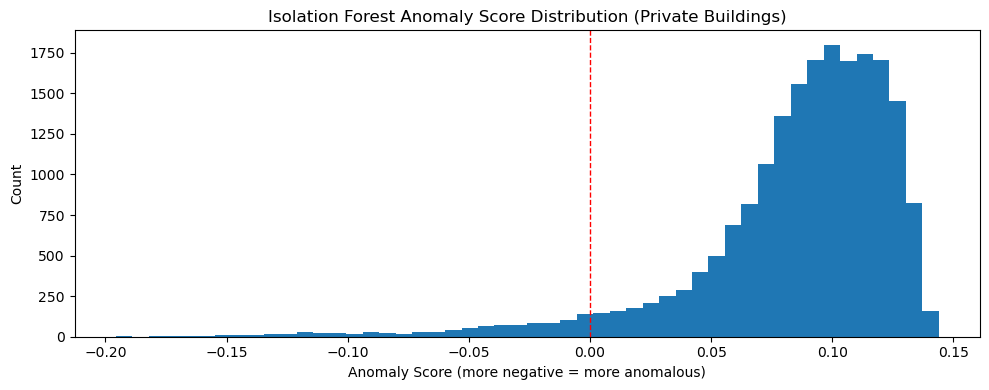

In [71]:
plt.figure(figsize=(10, 4))
plt.hist(if_scores, bins=50)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.title('Isolation Forest Anomaly Score Distribution (Private Buildings)')
plt.xlabel('Anomaly Score (more negative = more anomalous)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [72]:
# build the results dataframe so we have something concrete to validate against.
# rejoin the anomaly scores back to the identifier columns so we can see 
# which actual buildings got flagged
# This is a ranked list of the most anomalous buildings with their addresses and
# emissions figures
results_df = model_df[['property_id', 'bbl_clean', 'address_1', 'property_name',
                        'ownername', 'peer_group',
                        'total_location_based_ghg']].copy()

# Reconstruct borough from one-hot encoded columns
borough_cols = [c for c in model_df.columns if c.startswith('borough_')]
results_df['borough'] = model_df[borough_cols].idxmax(axis=1).str.replace('borough_', '')

results_df['if_score'] = if_scores
results_df['if_anomaly'] = if_labels

results_df = results_df.sort_values('if_score', ascending=True)

print(results_df.head(10))

      property_id   bbl_clean             address_1  \
5895      5925243  2051410120  Co-Op City Boulevard   
231       2640593  4071170003         189-02 64 Ave   
5435      4972273  1016560001     2085-2086 2nd Ave   
16440    31808567  4124950002   169-65 137th Avenue   
13351    15679315  1013730001       595 Main Street   
4277      4398351  1011167501     20 W. 64Th Street   
20182    53381792  1002630008               Various   
3615      3616164  1007520001        321 Eighth Ave   
12436    12002863  1007027502    553 W. 30Th Street   
13129    15404602  1007027503  560 West 33rd Street   

                        property_name                       ownername  \
5895                       Co-Op City            RIVERBAY CORPORATION   
231            QFR (BBL - 4071170003)       QUEENS FRESH MEADOWS, LLC   
5435              Franklin Plaza 1656   NYC HOUSING DEVELOPMENT CORP.   
16440       Rochdale Village - Campus            ROCHDALE VILLAGE INC   
13351  Westview - 595-625 Mai

### 5.2 Isolation Forest — Split by Size

To address the xl bias identified in section 5.1, we split the private building
population into xl (over 250,000 sq ft) and non-xl subsets and fit separate Isolation
Forest models. Each building is now only compared against structurally similar peers
in terms of scale.

**Populations:**
- XL buildings: 1,286
- Non-XL buildings: 18,433

**Owner Distribution — Full Population**
Buildings with no identifiable owner ("UNAVAILABLE OWNER" or "NAME NOT ON FILE")
are flagged at a higher rate than the 5% baseline. Unknown ownership combined with
anomalous emissions reporting is a compounded risk signal — these buildings are harder
to hold accountable and warrant priority attention regardless of size group.

> #### Key Finding: XL Peer Median Suggests Widespread Under-reporting

> XL peer group medians range from 1,871 to 2,424 metric tons annually for buildings
over 250,000 sq ft. At the LL97 2024-2029 compliance limit of 0.00675 metric tons
per square foot, a 250,000 sq ft building at exactly the cap would emit 1,687 metric
tons. The typical xl building in this dataset is reporting just above the legal limit
— without any documented retrofits.

> This suggests the xl flagged buildings (reporting significantly above peers) may
actually be the more honest reporters, while the unflagged xl majority is potentially
under-reporting strategically near the compliance threshold. The xl model may be
identifying compliant reporters rather than misreporters.

> This finding motivates the bunching test in section 5.5 — if buildings are clustering
statistically near the compliance threshold, that is self-validating evidence of
strategic reporting independent of the model.

In [ ]:
total_unavailable = model_df[model_df['ownername'] == 'UNAVAILABLE OWNER'].shape[0]
print(f"Unavailable owner flagged: 127 / {total_unavailable} ({127/total_unavailable:.1%})")

In [74]:
xl_flagged_df = results_df[
    (results_df['if_anomaly'] == -1) & 
    (results_df['peer_group'].str.endswith('xl'))
]
print(xl_flagged_df[['address_1', 'property_name', 'peer_group', 
                      'total_location_based_ghg', 'if_score']].head(20))

                                   address_1  \
5895                    Co-Op City Boulevard   
231                            189-02 64 Ave   
5435                       2085-2086 2nd Ave   
16440                    169-65 137th Avenue   
13351                        595 Main Street   
4277                       20 W. 64Th Street   
20182                                Various   
3615                          321 Eighth Ave   
12436                     553 W. 30Th Street   
13129                   560 West 33rd Street   
15908           272-10 Grand Central Parkway   
16073               2000 East Tremont Avenue   
13375                     829 Schenck Avenue   
12053                           54 Boerum St   
20334                   310 Greenwich Street   
17612                       87 TEN EYCK WALK   
16156                 224-01 Hillside Avenue   
17467  56-10 &amp; 51-32 BEACH CHANNEL DRIVE   
12280             773 Concourse Village East   
2865                           560 10 Av

In [76]:
# Split model_df into xl and non-xl populations
xl_mask = model_df['peer_group'].str.endswith('xl')
model_df_xl = model_df[xl_mask].copy()
model_df_nonxl = model_df[~xl_mask].copy()

print(f"XL buildings: {model_df_xl.shape[0]}")
print(f"Non-XL buildings: {model_df_nonxl.shape[0]}")

XL buildings: 1286
Non-XL buildings: 18433


In [77]:
# Build feature matrix for non-XL buildings
X_nonxl = model_df_nonxl.drop(columns=exclude_cols, errors='ignore')

# Encode age and size buckets
X_nonxl = pd.get_dummies(X_nonxl, columns=['age_bucket', 'size_bucket'], drop_first=False)

# Peer group imputation
X_nonxl_imputed = X_nonxl.copy()
for col in X_nonxl_imputed.select_dtypes(include='float64').columns:
    X_nonxl_imputed[col] = X_nonxl_imputed.groupby(
        model_df_nonxl['peer_group'])[col].transform(
        lambda x: x.fillna(x.median())
    )

print(f"Nulls remaining: {X_nonxl_imputed.isnull().sum().sum()}")

# Scale
scaler_nonxl = StandardScaler()
X_scaled_nonxl = pd.DataFrame(
    scaler_nonxl.fit_transform(X_nonxl_imputed),
    columns=X_nonxl_imputed.columns
)

# Fit model
iso_nonxl = IsolationForest(contamination=0.05, random_state=42)
iso_nonxl.fit(X_scaled_nonxl)

if_labels_nonxl = iso_nonxl.predict(X_scaled_nonxl)
if_scores_nonxl = iso_nonxl.decision_function(X_scaled_nonxl)

print(f"Anomalies flagged: {(if_labels_nonxl == -1).sum()}")
print(f"Score range: {if_scores_nonxl.min():.3f} to {if_scores_nonxl.max():.3f}")

Nulls remaining: 0
Anomalies flagged: 922
Score range: -0.166 to 0.134


In [78]:
results_nonxl = model_df_nonxl[['property_id', 'bbl_clean', 'address_1', 'property_name',
                                  'ownername', 'peer_group',
                                  'total_location_based_ghg']].copy()

borough_cols = [c for c in model_df_nonxl.columns if c.startswith('borough_')]
results_nonxl['borough'] = model_df_nonxl[borough_cols].idxmax(axis=1).str.replace('borough_', '')

results_nonxl['if_score'] = if_scores_nonxl
results_nonxl['if_anomaly'] = if_labels_nonxl
results_nonxl = results_nonxl.sort_values('if_score', ascending=True)

flagged_nonxl = results_nonxl[results_nonxl['if_anomaly'] == -1]

print(flagged_nonxl['peer_group'].value_counts())
xl_share = flagged_nonxl['peer_group'].str.endswith('xl').mean()
print(f"\nXL share of flagged: {xl_share:.1%}")
print(flagged_nonxl[['address_1', 'property_name', 'peer_group', 
                       'total_location_based_ghg', 'if_score']].head(10))

peer_group
post_war_large     281
recent_large       148
late_20c_large     117
modern_large        82
pre_war_large       60
post_war_small      58
pre_war_small       39
modern_small        32
post_war_medium     26
pre_war_medium      19
recent_small        19
recent_medium       17
late_20c_small       8
late_20c_medium      8
modern_medium        8
Name: count, dtype: int64

XL share of flagged: 0.0%
                       address_1  \
584       364 A Greenwich Street   
13299  56-10 Beach Channel Drive   
13145  51-32 Beach Channel Drive   
15450      230 East 123rd Street   
61                   312 8th Ave   
12206      315 East 106th Street   
12205            2078 2nd Avenue   
12204      324 East 108th Street   
12208      325 East 106th Street   
12203      334 East 108th Street   

                                       property_name      peer_group  \
584                 Stellar - 364 A Greenwich Street  late_20c_large   
13299                  Ocean Bay I (1-6/15-20/23-2

In [79]:
X_xl = model_df_xl.drop(columns=exclude_cols, errors='ignore')
X_xl = pd.get_dummies(X_xl, columns=['age_bucket', 'size_bucket'], drop_first=False)

X_xl_imputed = X_xl.copy()
for col in X_xl_imputed.select_dtypes(include='float64').columns:
    X_xl_imputed[col] = X_xl_imputed.groupby(
        model_df_xl['peer_group'])[col].transform(
        lambda x: x.fillna(x.median())
    )

print(f"Nulls remaining: {X_xl_imputed.isnull().sum().sum()}")

scaler_xl = StandardScaler()
X_scaled_xl = pd.DataFrame(
    scaler_xl.fit_transform(X_xl_imputed),
    columns=X_xl_imputed.columns
)

iso_xl = IsolationForest(contamination=0.05, random_state=42)
iso_xl.fit(X_scaled_xl)

if_labels_xl = iso_xl.predict(X_scaled_xl)
if_scores_xl = iso_xl.decision_function(X_scaled_xl)

print(f"Anomalies flagged: {(if_labels_xl == -1).sum()}")
print(f"Score range: {if_scores_xl.min():.3f} to {if_scores_xl.max():.3f}")

Nulls remaining: 0
Anomalies flagged: 65
Score range: -0.177 to 0.119


In [80]:
results_xl = model_df_xl[['property_id', 'bbl_clean', 'address_1', 'property_name',
                            'ownername', 'peer_group',
                            'total_location_based_ghg']].copy()

borough_cols = [c for c in model_df_xl.columns if c.startswith('borough_')]
results_xl['borough'] = model_df_xl[borough_cols].idxmax(axis=1).str.replace('borough_', '')

results_xl['if_score'] = if_scores_xl
results_xl['if_anomaly'] = if_labels_xl
results_xl = results_xl.sort_values('if_score', ascending=True)

flagged_xl = results_xl[results_xl['if_anomaly'] == -1]

print(flagged_xl['peer_group'].value_counts())
print(flagged_xl[['address_1', 'property_name', 'peer_group',
                   'total_location_based_ghg', 'if_score']].head(10))

peer_group
post_war_xl    33
recent_xl      12
late_20c_xl    10
pre_war_xl      7
modern_xl       3
Name: count, dtype: int64
                          address_1  \
5435              2085-2086 2nd Ave   
16073      2000 East Tremont Avenue   
5895           Co-Op City Boulevard   
16440           169-65 137th Avenue   
4156                  252 First Ave   
13351               595 Main Street   
15908  272-10 Grand Central Parkway   
20384          303 East 57th Street   
19086              568 Grand Street   
12280    773 Concourse Village East   

                                       property_name   peer_group  \
5435                             Franklin Plaza 1656  post_war_xl   
16073        Parkchester Full Campus (North + South)  post_war_xl   
5895                                      Co-Op City  post_war_xl   
16440                      Rochdale Village - Campus  post_war_xl   
4156                                 Stuyvesant Town  post_war_xl   
13351                 Westvie

### Results Comparisons XL vs. nonXL

In [94]:
# Add peer group medians to both result sets
peer_medians_nonxl = model_df_nonxl.groupby('peer_group')['total_location_based_ghg'].median()
peer_medians_nonxl.name = 'peer_median_ghg'

peer_medians_xl = model_df_xl.groupby('peer_group')['total_location_based_ghg'].median()
peer_medians_xl.name = 'peer_median_ghg'

flagged_nonxl_sorted = flagged_nonxl_sorted.merge(
    peer_medians_nonxl, on='peer_group'
)
flagged_nonxl_sorted['gap_vs_peer'] = (
    flagged_nonxl_sorted['total_location_based_ghg'] - 
    flagged_nonxl_sorted['peer_median_ghg']
)

flagged_xl_sorted = flagged_xl_sorted.merge(
    peer_medians_xl, on='peer_group'
)
flagged_xl_sorted['gap_vs_peer'] = (
    flagged_xl_sorted['total_location_based_ghg'] - 
    flagged_xl_sorted['peer_median_ghg']
)

cols = ['address_1', 'property_name', 'peer_group',
        'total_location_based_ghg', 'peer_median_ghg',
        'gap_vs_peer', 'if_score']

print("=== Non-XL Flagged Buildings ===")
print(flagged_nonxl_sorted[cols].head(10))

print("\n=== XL Flagged Buildings ===")
print(flagged_xl_sorted[cols].head(10))

=== Non-XL Flagged Buildings ===
                   address_1                                  property_name  \
0     364 A Greenwich Street               Stellar - 364 A Greenwich Street   
1  56-10 Beach Channel Drive                  Ocean Bay I (1-6/15-20/23-24)   
2  51-32 Beach Channel Drive                      Ocean Bay II (7-14/21-22)   
3      230 East 123rd Street                          230 East 123rd Street   
4                312 8th Ave  Mutual Redevelopment -Penn South - Building 4   
5      315 East 106th Street                                 315 E 106th St   
6            2078 2nd Avenue                                   2078 2nd Ave   
7      324 East 108th Street                                 324 E 108th St   
8      325 East 106th Street                                 325 E 106th St   
9      334 East 108th Street                                 334 E 108th St   

       peer_group  total_location_based_ghg  peer_median_ghg  gap_vs_peer  \
0  late_20c_large   

In [95]:
print(model_df_xl.groupby('peer_group')['total_location_based_ghg'].agg(
    ['median', 'mean', 'count']
).round(0))

             median    mean  count
peer_group                        
late_20c_xl  2424.0  3223.0    225
modern_xl    2267.0  2689.0    167
post_war_xl  1912.0  3368.0    500
pre_war_xl   1896.0  2372.0    156
recent_xl    1871.0  2298.0    238


### 5.3 Contamination Sensitivity Analysis

We test three contamination values (0.03, 0.05, 0.10) to assess how stable the flagged
set is across different assumptions. Buildings flagged at all three values are the most
robust anomaly candidates.

In [ ]:
contamination_values = [0.03, 0.05, 0.10]
sensitivity_results = {}

for c in contamination_values:
    iso = IsolationForest(contamination=c, random_state=42)
    iso.fit(X_scaled)
    labels = iso.predict(X_scaled)
    flagged_ids = set(model_df[labels == -1]['property_id'])
    sensitivity_results[c] = flagged_ids
    print(f"contamination={c}: {len(flagged_ids)} buildings flagged")

# Check overlap — buildings flagged across all three values are most robust
core_anomalies = sensitivity_results[0.03] & sensitivity_results[0.05] & sensitivity_results[0.10]
print(f"\nFlagged at all three contamination levels: {len(core_anomalies)}")
print(f"Share of 0.05 flagged set: {len(core_anomalies)/len(sensitivity_results[0.05]):.1%}")

In [ ]:
core_df = results_df[results_df['property_id'].isin(core_anomalies)]
print(core_df['peer_group'].value_counts())
print(f"\nXL share of core anomalies: {core_df['peer_group'].str.endswith('xl').mean():.1%}")

In [ ]:
print(f"XL share of core anomalies: {core_df['peer_group'].str.endswith('xl').mean():.1%}")

In [ ]:
core_non_xl = core_df[~core_df['peer_group'].str.endswith('xl')]
print(core_non_xl[['address_1', 'property_name', 'ownername', 
                    'peer_group', 'total_location_based_ghg', 
                    'if_score']].head(20))

### 5.4 Local Outlier Factor

Local Outlier Factor (LOF) detects anomalies by comparing each building's local density
to the density of its neighbors. A building is flagged as anomalous if it exists in a
significantly less dense region than its neighbors — meaning it is isolated relative to
similar buildings in feature space.

LOF complements Isolation Forest by detecting a different kind of anomaly. IF finds
buildings that are globally unusual across the full feature space. LOF finds buildings
that are locally unusual relative to their immediate neighbors. A building can be one
without being the other.

**Parameters:**
- `n_neighbors=20` — number of neighbors used to estimate local density. Tested at
20, 50, and 100; overlap with IF improved modestly from 20.2% to 30.5%, suggesting
the disagreement between models reflects genuine algorithmic difference rather than
a tuning issue.
- `contamination=0.05` — matches Isolation Forest for consistent comparison.

**Key difference from Isolation Forest:**
LOF scores come from `negative_outlier_factor_` rather than `decision_function`. Scores
are only available after `fit_predict` — LOF cannot score new data after fitting. This
is acceptable for batch scoring the full dataset but means LOF cannot be deployed
for real-time scoring of new buildings without refitting.

**Output:**
- `lof_labels_nonxl` — binary flag: -1 = anomaly, 1 = normal
- `lof_scores_nonxl` — continuous score. More negative = more anomalous.
Score range is on a different scale than Isolation Forest (-50.229 to -0.948)
and is not directly comparable across models.

**Results:** 922 buildings flagged (5% of 18,433 non-xl private buildings).

In [96]:
# LOF detects anomalies relative to local neighborhood density
# n_neighbors=20 is a reasonable default for this dataset size
# contamination=0.05 matches Isolation Forest for comparison
lof_nonxl = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_labels_nonxl = lof_nonxl.fit_predict(X_scaled_nonxl)

# negative_outlier_factor_ — more negative = more anomalous
# matches Isolation Forest score direction for consistency
lof_scores_nonxl = lof_nonxl.negative_outlier_factor_

print(f"Anomalies flagged: {(lof_labels_nonxl == -1).sum()}")
print(f"Score range: {lof_scores_nonxl.min():.3f} to {lof_scores_nonxl.max():.3f}")

Anomalies flagged: 922
Score range: -50.229 to -0.948


In [97]:
results_lof_nonxl = model_df_nonxl[['property_id', 'bbl_clean', 'address_1', 
                                      'property_name', 'ownername', 
                                      'peer_group', 'total_location_based_ghg']].copy()

borough_cols = [c for c in model_df_nonxl.columns if c.startswith('borough_')]
results_lof_nonxl['borough'] = model_df_nonxl[borough_cols].idxmax(axis=1).str.replace('borough_', '')

results_lof_nonxl['lof_score'] = lof_scores_nonxl
results_lof_nonxl['lof_anomaly'] = lof_labels_nonxl
results_lof_nonxl = results_lof_nonxl.sort_values('lof_score', ascending=True)

# Check overlap with Isolation Forest
if_flagged_ids = set(flagged_nonxl_sorted['property_id'])
lof_flagged_ids = set(results_lof_nonxl[results_lof_nonxl['lof_anomaly'] == -1]['property_id'])

overlap = if_flagged_ids & lof_flagged_ids
print(f"Flagged by IF only: {len(if_flagged_ids - lof_flagged_ids)}")
print(f"Flagged by LOF only: {len(lof_flagged_ids - if_flagged_ids)}")
print(f"Flagged by both: {len(overlap)}")
print(f"Overlap rate: {len(overlap)/len(if_flagged_ids):.1%}")

Flagged by IF only: 736
Flagged by LOF only: 736
Flagged by both: 186
Overlap rate: 20.2%


In [98]:
lof_nonxl_50 = LocalOutlierFactor(n_neighbors=50, contamination=0.05)
lof_labels_50 = lof_nonxl_50.fit_predict(X_scaled_nonxl)
lof_flagged_50 = set(model_df_nonxl[lof_labels_50 == -1]['property_id'])

overlap_50 = if_flagged_ids & lof_flagged_50
print(f"n_neighbors=50 overlap with IF: {len(overlap_50)/len(if_flagged_ids):.1%}")

lof_nonxl_100 = LocalOutlierFactor(n_neighbors=100, contamination=0.05)
lof_labels_100 = lof_nonxl_100.fit_predict(X_scaled_nonxl)
lof_flagged_100 = set(model_df_nonxl[lof_labels_100 == -1]['property_id'])

overlap_100 = if_flagged_ids & lof_flagged_100
print(f"n_neighbors=100 overlap with IF: {len(overlap_100)/len(if_flagged_ids):.1%}")

n_neighbors=50 overlap with IF: 25.3%
n_neighbors=100 overlap with IF: 30.5%


In [99]:
overlap_df = results_lof_nonxl[
    results_lof_nonxl['property_id'].isin(overlap)
].merge(
    results_nonxl[['property_id', 'if_score', 'if_anomaly']],
    on='property_id'
).sort_values('lof_score', ascending=True)

print(f"Buildings flagged by both IF and LOF: {len(overlap_df)}")
print(overlap_df[['address_1', 'property_name', 'peer_group',
                   'total_location_based_ghg', 'if_score', 
                   'lof_score']].head(10))

Buildings flagged by both IF and LOF: 186
             address_1                                    property_name  \
0      1037 Shore Pkwy  Independence Gardens Owners 1 (1037 Shore Pkwy)   
1      1065 Shore Pkwy  Independence Gardens Owners 1 (1065 Shore Pkwy)   
2  169-65 137th Avenue                       Rochdale Village - 4436332   
3      51 Markham Lane                                  51 Markham Lane   
4    13 Primrose Place                                   13 Primrose Pl   
5       29 PRIMROSE PL                                   29 Primrose Pl   
6      2850 HYLAN BLVD                                  2850 Hylan Blvd   
7  81 Narrows Rd North    EWC Property Management : 81 Narrows Rd North   
8    12 Primrose Place                                   12 Primrose Pl   
9        9430 58th Ave    Rego Park Gardens Owners Corp (9430 58th Ave)   

       peer_group  total_location_based_ghg  if_score  lof_score  
0  post_war_small                      1.51 -0.033771 -16.196522 

In [100]:
overlap_df = overlap_df.merge(
    peer_medians_nonxl, on='peer_group'
)
overlap_df['pct_of_peer_median'] = (
    overlap_df['total_location_based_ghg'] / 
    overlap_df['peer_median_ghg'] * 100
).round(1)

print(overlap_df[['address_1', 'property_name', 'peer_group',
                   'total_location_based_ghg', 'peer_median_ghg',
                   'pct_of_peer_median', 'if_score', 
                   'lof_score']].head(10))

             address_1                                    property_name  \
0      1037 Shore Pkwy  Independence Gardens Owners 1 (1037 Shore Pkwy)   
1      1065 Shore Pkwy  Independence Gardens Owners 1 (1065 Shore Pkwy)   
2  169-65 137th Avenue                       Rochdale Village - 4436332   
3      51 Markham Lane                                  51 Markham Lane   
4    13 Primrose Place                                   13 Primrose Pl   
5       29 PRIMROSE PL                                   29 Primrose Pl   
6      2850 HYLAN BLVD                                  2850 Hylan Blvd   
7  81 Narrows Rd North    EWC Property Management : 81 Narrows Rd North   
8    12 Primrose Place                                   12 Primrose Pl   
9        9430 58th Ave    Rego Park Gardens Owners Corp (9430 58th Ave)   

       peer_group  total_location_based_ghg  peer_median_ghg  \
0  post_war_small                      1.51           199.78   
1  post_war_small                      0.24   

In [101]:
# Save the overlap buildings as your highest confidence audit targets
high_confidence_targets = overlap_df.sort_values('lof_score', ascending=True)
print(f"High confidence audit targets (flagged by both IF and LOF): {len(high_confidence_targets)}")

High confidence audit targets (flagged by both IF and LOF): 186


### 5.5 DBSCAN


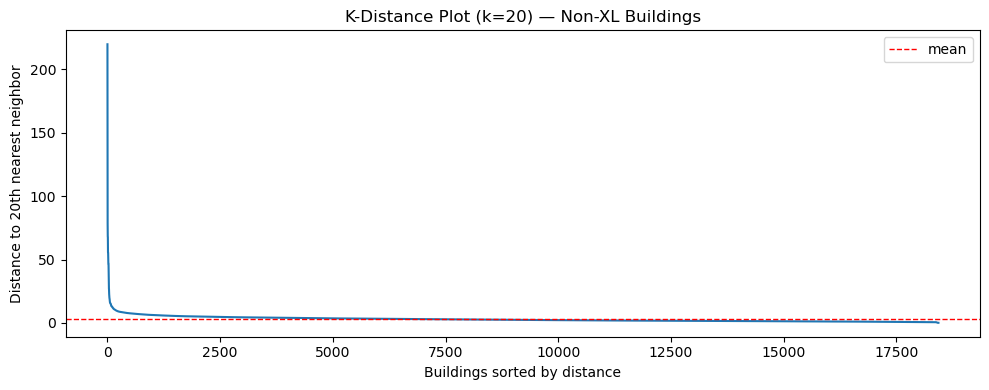

Mean k-distance: 2.933
Median k-distance: 2.355
95th percentile: 6.351


In [103]:
# Use same k as LOF n_neighbors for consistency
k = 20
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled_nonxl)
distances, _ = nbrs.kneighbors(X_scaled_nonxl)

# Sort distances to kth neighbor
k_distances = np.sort(distances[:, k-1])[::-1]

plt.figure(figsize=(10, 4))
plt.plot(k_distances)
plt.axhline(y=k_distances.mean(), color='red', linestyle='--', linewidth=1, label='mean')
plt.title('K-Distance Plot (k=20) — Non-XL Buildings')
plt.xlabel('Buildings sorted by distance')
plt.ylabel(f'Distance to {k}th nearest neighbor')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean k-distance: {k_distances.mean():.3f}")
print(f"Median k-distance: {np.median(k_distances):.3f}")
print(f"95th percentile: {np.percentile(k_distances, 95):.3f}")

In [106]:
eps_values = [4.0, 4.5, 5.0]

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled_nonxl)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    print(f"eps={eps}: {n_clusters} clusters, {n_noise} noise points ({n_noise/len(labels):.1%})")

eps=4.0: 88 clusters, 1021 noise points (5.5%)
eps=4.5: 62 clusters, 706 noise points (3.8%)
eps=5.0: 39 clusters, 493 noise points (2.7%)


In [107]:
dbscan = DBSCAN(eps=4.0, min_samples=5)
dbscan_labels_nonxl = dbscan.fit_predict(X_scaled_nonxl)

n_clusters = len(set(dbscan_labels_nonxl)) - (1 if -1 in dbscan_labels_nonxl else 0)
n_noise = (dbscan_labels_nonxl == -1).sum()

print(f"Clusters found: {n_clusters}")
print(f"Noise points (anomalies): {n_noise} ({n_noise/len(dbscan_labels_nonxl):.1%})")

Clusters found: 88
Noise points (anomalies): 1021 (5.5%)


In [108]:
dbscan_flagged_ids = set(model_df_nonxl[dbscan_labels_nonxl == -1]['property_id'])

if_only = if_flagged_ids - lof_flagged_ids - dbscan_flagged_ids
lof_only = lof_flagged_ids - if_flagged_ids - dbscan_flagged_ids
dbscan_only = dbscan_flagged_ids - if_flagged_ids - lof_flagged_ids
all_three = if_flagged_ids & lof_flagged_ids & dbscan_flagged_ids
any_two = (if_flagged_ids & lof_flagged_ids) | (if_flagged_ids & dbscan_flagged_ids) | (lof_flagged_ids & dbscan_flagged_ids)

print(f"Flagged by IF only: {len(if_only)}")
print(f"Flagged by LOF only: {len(lof_only)}")
print(f"Flagged by DBSCAN only: {len(dbscan_only)}")
print(f"Flagged by all three: {len(all_three)}")
print(f"Flagged by any two: {len(any_two)}")

Flagged by IF only: 416
Flagged by LOF only: 611
Flagged by DBSCAN only: 429
Flagged by all three: 147
Flagged by any two: 631


In [109]:
all_three_df = model_df_nonxl[
    model_df_nonxl['property_id'].isin(all_three)
][['property_id', 'bbl_clean', 'address_1', 'property_name', 
   'ownername', 'peer_group', 'total_location_based_ghg']].copy()

# Add scores from each model
all_three_df = all_three_df.merge(
    results_nonxl[['property_id', 'if_score']], on='property_id'
).merge(
    results_lof_nonxl[['property_id', 'lof_score']], on='property_id'
)

# Add peer median and pct
all_three_df = all_three_df.merge(peer_medians_nonxl, on='peer_group')
all_three_df['pct_of_peer_median'] = (
    all_three_df['total_location_based_ghg'] / 
    all_three_df['peer_median_ghg'] * 100
).round(1)

all_three_df = all_three_df.sort_values('if_score', ascending=True)

print(f"Gold standard audit targets: {len(all_three_df)}")
print(all_three_df[['address_1', 'property_name', 'peer_group',
                     'total_location_based_ghg', 'peer_median_ghg',
                     'pct_of_peer_median', 'if_score', 
                     'lof_score']].head(15))

Gold standard audit targets: 147
                              address_1  \
75            51-32 Beach Channel Drive   
84                230 East 123rd Street   
2                           312 8th Ave   
25                  169-65 137th Avenue   
11                    56 EAST 59 STREET   
105                35-85 Holland Avenue   
103                35-85 Holland Avenue   
104                35-85 Holland Avenue   
102                35-85 Holland Avenue   
134   500 PARK AVENUE;56 EAST 59 STREET   
7                         99-40 63 Road   
78                      1065 Second Ave   
112  524 HOWARD AVE NatGrid Placeholder   
33                   150 Brielle Avenue   
113                    524 East 72nd St   

                                     property_name      peer_group  \
75                       Ocean Bay II (7-14/21-22)  post_war_small   
84                           230 East 123rd Street  late_20c_large   
2    Mutual Redevelopment -Penn South - Building 4  post_war_large  

In [110]:
xl_in_all_three = all_three & set(flagged_xl['property_id'])
print(f"Buildings flagged by all three models AND xl model: {len(xl_in_all_three)}")

Buildings flagged by all three models AND xl model: 0


#### 5.6 Model Comparison and High Confidence Audit Targets

#### Algorithm Overview
Three fundamentally different anomaly detection approaches were applied to the non-xl
private building population:

- **Isolation Forest** — identifies global outliers by randomly partitioning the feature
space. Buildings isolated in fewer splits are flagged as anomalous.
- **Local Outlier Factor** — identifies local outliers by comparing each building's
density to its nearest neighbors. Buildings in significantly less dense regions are flagged.
- **DBSCAN** — density-based clustering that labels points failing to form clusters as
noise. Noise points are the anomalies. eps=4.0 selected via k-distance plot elbow,
producing 5.5% noise rate closest to the 5% contamination threshold.

#### Overlap Analysis
| | IF | LOF | DBSCAN |
|---|---|---|---|
| Total flagged | 922 | 922 | 1,021 |
| Flagged by this model only | 416 | 611 | 429 |
| Flagged by all three | 147 | 147 | 147 |

- **Flagged by IF only:** 416
- **Flagged by LOF only:** 611
- **Flagged by DBSCAN only:** 429
- **Flagged by any two models:** 631
- **Flagged by all three models:** 147

Low pairwise overlap (20.2% between IF and LOF) reflects genuine algorithmic difference
rather than a tuning issue — LOF n_neighbors was tested at 20, 50, and 100 with overlap
improving only modestly from 20.2% to 30.5%. Both algorithms are detecting real signal,
just different kinds.

#### High Confidence Audit Targets
The 147 buildings flagged by all three models are the highest confidence audit targets.
Key patterns in this set:

- All 147 report above their peer group median — the models are consistently finding
over-reporters rather than under-reporters in the non-xl population
- **Holland Avenue cluster** — four buildings (35, 55, 65, 85 Holland Ave) all flagged,
all `late_20c_small`, reporting 209–243% of peer median. Systematic over-reporting
across a development.
- **500 Park Avenue** — appears as both a CHILD and PARENT submission, both flagged.
Campus vs building-level reporting inconsistency.
- **524 Howard Ave "NatGrid Placeholder"** — the word "Placeholder" in the property
name suggests a test or incomplete submission that entered the live dataset.

#### Audit Priority Tiers

**Tier 1 (highest confidence) — 147 buildings**
Flagged by all three models. Agreement across IF, LOF, and DBSCAN represents the
strongest possible signal from unsupervised anomaly detection without ground truth labels.

**Tier 2 (moderate confidence) — 484 buildings**
Flagged by any two of the three models. Worth investigating after Tier 1 is exhausted.

**Tier 3 (scale anomalies) — 65 buildings**
Flagged by Isolation Forest within the xl population. Anomalous relative to other xl
buildings — the xl peer median finding (section 5.2) suggests these may be more honest
reporters in a population with widespread under-reporting.

**Separate population — NYCHA (500 buildings)**
Set aside due to structural differences in campus-style public housing reporting.
Requires its own analysis framework before audit prioritization.

#### Key Findings from Tier 1 Set

- **Shore Parkway cluster** — 7 buildings from the same Independence Gardens development
flagged by all three models. Three buildings report 0.1%, 0.2%, and 0.8% of their peer
median — near-zero emissions for occupied multifamily buildings is implausible. The full
cluster ranges from 0.1% to 153.2% of peer median, suggesting systematic reporting
issues across the development rather than isolated errors.

- **Rochdale Village** — reporting 9,639% of peer median (69,443 metric tons against a
peer median of 720). Likely a campus-level submission being compared against individual
building peers — warrants separate investigation.

- **Holland Avenue cluster** — four buildings reporting 209–243% of peer median, all
flagged by all three models.

- **Primrose Place** — one building flagged by all three (76.7% of peer median). Four
additional Primrose Place buildings appear in Tier 2 (flagged by IF and LOF only).
Geographic clustering suggests a systematic reporting practice for that development.

The `pct_of_peer_median` column is the most interpretable metric for a non-technical
audience — a building reporting 0.1% of what similar buildings report requires no
statistical knowledge to identify as suspicious.

In [111]:
shore_pkwy = all_three_df[all_three_df['address_1'].str.contains('Shore', case=False, na=False)]
print(shore_pkwy[['address_1', 'property_name', 'pct_of_peer_median']])

               address_1                                    property_name  \
52       1051 Shore Pkwy  Independence Gardens Owners 1 (1051 Shore Pkwy)   
54       1083 Shore Pkwy  Independence Gardens Owners 1 (1083 Shore Pkwy)   
129  80-39 SHORE PARKWAY              Esquire - 8039 SHORE PARKWAY(child)   
51       1037 Shore Pkwy  Independence Gardens Owners 1 (1037 Shore Pkwy)   
53       1065 Shore Pkwy  Independence Gardens Owners 1 (1065 Shore Pkwy)   
48       1001 Shore Pkwy  Independence Gardens Owners 2 (1001 Shore Pkwy)   
23       1259 Shore Pkwy                      Jalen: 8847 Bay 16th Street   

     pct_of_peer_median  
52                 65.4  
54                 44.3  
129               153.2  
51                  0.8  
53                  0.1  
48                  0.2  
23                 58.0  


In [112]:
primrose = all_three_df[all_three_df['address_1'].str.contains('Primrose', case=False, na=False)]
print(primrose[['address_1', 'property_name', 'pct_of_peer_median']])

         address_1   property_name  pct_of_peer_median
38  29 PRIMROSE PL  29 Primrose Pl                76.7


### 5.7 Bunching Test

A bunching test checks for statistically significant density of buildings reporting just
below the LL97 compliance threshold. Unlike the anomaly detection models, this test
requires no labels and validates itself — strategic threshold targeting produces a
distinctive asymmetric density spike that cannot arise from honest random variation.

**Method:** Each building's emissions cap is calculated as `multifamily_housing_gross ×
0.00675 metric tons CO2e per square foot` — the LL97 2024-2029 intensity limit for
multifamily buildings. Buildings within 20% below or above their individual cap are
counted.

**Results:**
- Buildings within 20% below cap: 4,014
- Buildings within 20% above cap: 1,692
- **Ratio below/above: 2.37**

Under honest reporting, this ratio should be close to 1.0 — buildings would be
distributed roughly symmetrically around the compliance threshold. A ratio of 2.37
means buildings are more than twice as likely to report just below the threshold than
just above it.

The histogram confirms this visually — a sharp spike immediately left of the cap
with a thin tail to the right. This is the classic bunching signature of strategic
threshold targeting documented across regulatory contexts globally.

**Significance:** This finding is independent of and corroborates the anomaly detection
models. It suggests the under-reporting pattern is not limited to the 147 Tier 1
buildings — it is systemic across the non-xl private building population. The scale
of the effect (2.37x asymmetry across 5,706 buildings near the threshold) points to
widespread strategic compliance reporting rather than isolated data errors.

Buildings within 20% below cap: 4014
Buildings within 20% above cap: 1692
Ratio below/above: 2.37


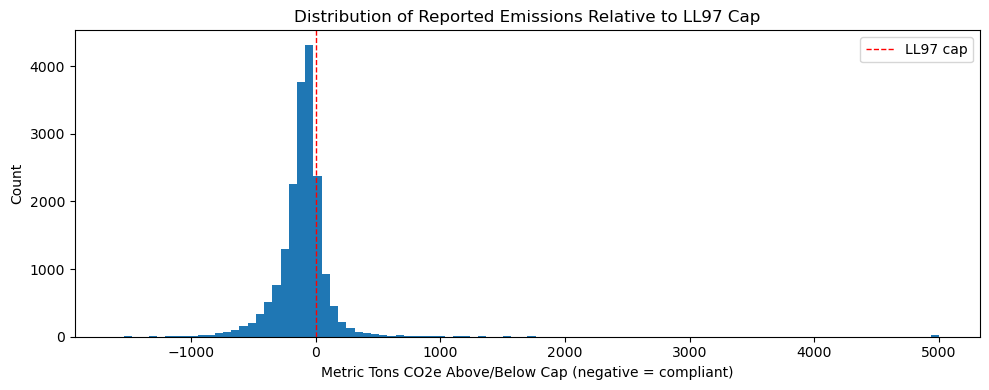

In [113]:
# LL97 2024-2029 emissions intensity limit for multifamily
LL97_CAP = 0.00675  # metric tons CO2e per square foot per year

# Calculate each building's emissions cap based on its square footage
model_df_nonxl_bunching = model_df_nonxl.copy()
model_df_nonxl_bunching['emissions_cap'] = (
    model_df_nonxl_bunching['multifamily_housing_gross'] * LL97_CAP
)

# Calculate how far each building is from its cap
# negative = under cap (compliant), positive = over cap (non-compliant)
model_df_nonxl_bunching['distance_from_cap'] = (
    model_df_nonxl_bunching['total_location_based_ghg'] - 
    model_df_nonxl_bunching['emissions_cap']
)

# Focus on a narrow window around the cap
# Buildings reporting within 20% below or above their cap
window = 0.20
just_below = model_df_nonxl_bunching[
    (model_df_nonxl_bunching['distance_from_cap'] >= -model_df_nonxl_bunching['emissions_cap'] * window) &
    (model_df_nonxl_bunching['distance_from_cap'] < 0)
]
just_above = model_df_nonxl_bunching[
    (model_df_nonxl_bunching['distance_from_cap'] >= 0) &
    (model_df_nonxl_bunching['distance_from_cap'] <= model_df_nonxl_bunching['emissions_cap'] * window)
]

print(f"Buildings within 20% below cap: {len(just_below)}")
print(f"Buildings within 20% above cap: {len(just_above)}")
print(f"Ratio below/above: {len(just_below)/len(just_above):.2f}")

# Plot distribution around the cap
plt.figure(figsize=(10, 4))
plt.hist(model_df_nonxl_bunching['distance_from_cap'].clip(-5000, 5000), bins=100)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1, label='LL97 cap')
plt.title('Distribution of Reported Emissions Relative to LL97 Cap')
plt.xlabel('Metric Tons CO2e Above/Below Cap (negative = compliant)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

### 5.8 Cross-reference Against DOB Violations